# 任务一：Fashion-MNIST 基础多层感知机实践

这份 notebook 会带着你一步一步完成实验三的第 1 个任务。

整个流程可以分成下面 8 步：

1. 导入库，并设置实验环境。
2. 加载 Fashion-MNIST 数据集，认识数据长什么样。
3. 按题目要求划分训练集、验证集和测试集。
4. 构建一个基础多层感知机：`784 -> 256 -> 10`。
5. 定义训练和验证函数。
6. 按要求训练 20 轮。
7. 绘制损失曲线和准确率曲线。
8. 在测试集上做最终评估。

如果你是第一次做深度学习实验，建议从上到下依次运行，不要跳着执行。


## 第 1 步：导入库并设置实验环境

这一部分先把实验环境搭好。

我们用到的库分成 4 类：

- Python 标准库：`copy`、`random`、`time`、`Path`
  用来做参数备份、随机种子控制、计时和路径处理。
- 数据分析与可视化：`pandas`、`matplotlib`、`seaborn`
  用来记录训练结果、画图和做简单展示。
- 深度学习相关：`torch`、`torchvision`
  用来定义模型、加载数据和训练网络。
- notebook 显示工具：`display`
  用来把表格显示得更整齐。

下面这些超参数后面会一直用到：

- `RANDOM_SEED = 42`
  固定随机种子，让数据划分和训练过程尽量可复现。
- `BATCH_SIZE = 64`
  每个 batch 放多少张图片进入模型。
- `NUM_EPOCHS = 20`
  训练轮数，题目要求就是 20 轮。
- `LEARNING_RATE = 1e-3`
  学习率，决定参数每次更新的步子有多大。
- `HIDDEN_DIM = 256`
  隐藏层神经元个数，题目要求为 256。
- `VALID_RATIO = 0.1`
  从训练集中划出 10% 作为验证集。


In [1]:
# 忽略一些不影响实验结论的警告，避免输出太乱
import warnings
warnings.filterwarnings("ignore")

# 标准库
import copy
import random
import time
from pathlib import Path
from typing import Optional

# 数据分析和画图
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# notebook 中表格显示更整齐
from IPython.display import display

# PyTorch 相关库
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# 设置默认绘图风格
sns.set_theme(style="whitegrid")

# 设置中文字体，防止标题和图例乱码
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

# 实验超参数
RANDOM_SEED = 42
BATCH_SIZE = 64
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3
HIDDEN_DIM = 256
VALID_RATIO = 0.1

# Fashion-MNIST 一共 10 个类别
CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]


def set_seed(seed: int) -> None:
    """
    固定随机种子。

    参数：
    - seed: 随机种子的取值。
      只要这个值保持不变，很多随机过程都会尽量保持一致。
    """
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_device() -> torch.device:
    """
    自动选择运行设备。

    返回值：
    - 如果当前机器支持 CUDA，就返回 GPU。
    - 否则返回 CPU。
    """
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


## 第 2 步：加载数据并认识 Fashion-MNIST

Fashion-MNIST 是一个服饰图像分类数据集，可以把它看成“衣服版 MNIST”。

它有下面这些特点：

- 每张图片大小都是 `28 x 28`
- 图片是灰度图，所以通道数为 1
- 一共有 10 个类别
- 训练集有 60000 张图片
- 测试集有 10000 张图片

题目要求我们完成这些预处理：

- 从训练集中再划分出验证集
- 将图像展平成 `784` 维向量
- 把像素值归一化到 `[0, 1]`
- 标签如果使用交叉熵损失，可以不手动转 one-hot

这里有一个特别重要的点：

`transforms.ToTensor()` 已经自动帮我们完成了两件事：

1. 把图片转成张量；
2. 把像素值从 `0~255` 缩放到 `0~1`。

所以后面不需要再手动除以 `255`。


### 先解释一下几个关键对象

- `datasets.FashionMNIST(...)`
  用来读取数据集。
- `random_split(...)`
  用来把训练集继续拆成训练集和验证集。
- `DataLoader(...)`
  用来分 batch 读取数据。

下面这些参数尤其值得记住：

- `root`
  数据集保存的位置。
- `train=True / False`
  取训练集还是测试集。
- `transform`
  对图像做的预处理。
- `batch_size`
  一次送进模型多少张图片。
- `shuffle=True`
  是否在每轮训练前打乱数据顺序。训练集一般要打乱，验证集和测试集一般不打乱。
- `pin_memory`
  如果使用 GPU，通常有助于提高数据传输效率。


当前设备： cuda
数据目录： d:\daima\cursor\人工智能技术与应用\实验三\fashion_mnist
完整训练集样本数：60000
训练集批次数：844
验证集批次数：94
测试集批次数：157


,类别编号,类别名称
0,0,T-shirt/top
1,1,Trouser
2,2,Pullover
3,3,Dress
4,4,Coat
5,5,Sandal
6,6,Shirt
7,7,Sneaker
8,8,Bag
9,9,Ankle boot


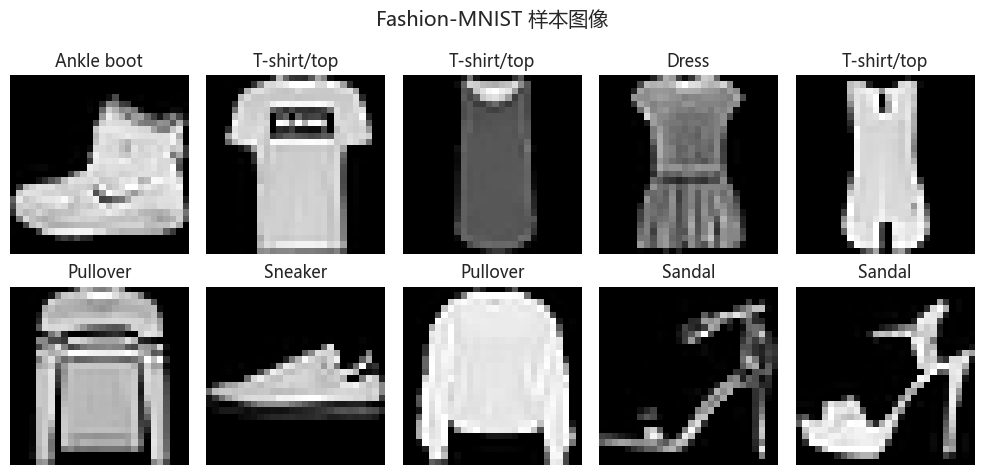

In [2]:
def build_dataloaders(data_root: Path):
    """
    加载 Fashion-MNIST，并划分训练集、验证集、测试集。

    参数：
    - data_root: 数据集所在根目录。

    返回值：
    - train_full: 完整训练集（后面展示样本图会用到）
    - train_loader: 训练集 DataLoader
    - valid_loader: 验证集 DataLoader
    - test_loader: 测试集 DataLoader
    """
    # ToTensor() 的作用：
    # 1. 把图片转成张量
    # 2. 把像素值从 [0, 255] 缩放到 [0, 1]
    transform = transforms.ToTensor()

    train_full = datasets.FashionMNIST(
        root=str(data_root),
        train=True,
        transform=transform,
        download=False,
    )
    test_dataset = datasets.FashionMNIST(
        root=str(data_root),
        train=False,
        transform=transform,
        download=False,
    )

    # 按题目要求，从训练集中再划出 10% 作为验证集
    valid_size = int(len(train_full) * VALID_RATIO)
    train_size = len(train_full) - valid_size

    # generator 的作用是固定随机划分结果
    split_generator = torch.Generator().manual_seed(RANDOM_SEED)
    train_dataset, valid_dataset = random_split(
        train_full,
        [train_size, valid_size],
        generator=split_generator,
    )

    loader_kwargs = {
        "batch_size": BATCH_SIZE,
        "num_workers": 0,
        "pin_memory": torch.cuda.is_available(),
    }

    train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
    valid_loader = DataLoader(valid_dataset, shuffle=False, **loader_kwargs)
    test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)

    return train_full, train_loader, valid_loader, test_loader


def show_sample_images(dataset):
    """
    展示若干样本图像。

    参数：
    - dataset: 可以按索引取出 (image, label) 的数据集对象。
    """
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for idx, ax in enumerate(axes.flat):
        image, label = dataset[idx]
        ax.imshow(image.squeeze(0), cmap="gray")
        ax.set_title(CLASS_NAMES[label])
        ax.axis("off")

    plt.suptitle("Fashion-MNIST 样本图像")
    plt.tight_layout()
    plt.show()


set_seed(RANDOM_SEED)
device = get_device()
data_root = Path.cwd() / "fashion_mnist"

train_full, train_loader, valid_loader, test_loader = build_dataloaders(data_root)

print("当前设备：", device)
print("数据目录：", data_root)
print(f"完整训练集样本数：{len(train_full)}")
print(f"训练集批次数：{len(train_loader)}")
print(f"验证集批次数：{len(valid_loader)}")
print(f"测试集批次数：{len(test_loader)}")

class_df = pd.DataFrame(
    {"类别编号": list(range(10)), "类别名称": CLASS_NAMES}
)
display(class_df)

show_sample_images(train_full)


## 第 3 步：构建基础多层感知机

题目要求的网络结构是：

`输入层(784) -> 隐藏层(256, ReLU) -> 输出层(10)`

下面逐个解释：

- `784`
  因为一张图片是 `28 x 28`，展平后就是 `28 * 28 = 784`。
- `256`
  隐藏层神经元个数，题目指定为 256。
- `ReLU()`
  隐藏层激活函数，用来引入非线性表达能力。
- `10`
  输出层神经元个数，因为一共有 10 个类别。

这里最容易困惑的一点是：

为什么代码里没有显式写 `Softmax`？

因为后面我们使用的是 `nn.CrossEntropyLoss()`，
它要求模型输出 logits，并在内部处理 softmax 相关计算，
所以模型这里直接输出 logits 就可以。


### 再解释一下模型相关参数

- `nn.Flatten()`
  把输入从 `[batch_size, 1, 28, 28]` 展平成 `[batch_size, 784]`。
- `nn.Linear(in_features, out_features)`
  全连接层。
  `in_features` 表示输入维度，`out_features` 表示输出维度。
- `hidden_dim`
  隐藏层宽度，这里就是 256。
- `num_classes`
  类别数，这里是 10。


In [3]:
class FashionMLP(nn.Module):
    """
    一层隐藏层的基础多层感知机。
    """

    def __init__(self, hidden_dim: int = HIDDEN_DIM, num_classes: int = 10) -> None:
        super().__init__()

        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # 输入 x 的形状通常是 [batch_size, 1, 28, 28]
        # 输出 logits 的形状通常是 [batch_size, 10]
        return self.network(x)


# 把模型放到 device 上运行
model = FashionMLP(hidden_dim=HIDDEN_DIM).to(device)

# 交叉熵损失适合多分类任务
# 输入：logits
# 标签：整数类别编号
criterion = nn.CrossEntropyLoss()

# Adam 优化器参数解释：
# model.parameters(): 需要被更新的模型参数
# lr=LEARNING_RATE: 学习率，这里是 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)
print("\n损失函数：", criterion)
print("优化器：", optimizer)


FashionMLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)

损失函数： CrossEntropyLoss()
优化器： Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## 第 4 步：定义训练与验证函数

为了让主流程更清楚，我们把训练部分拆成两个函数：

- `run_one_epoch()`
  跑一轮训练、验证或测试。
- `train_model()`
  循环训练很多轮，并记录历史结果。

这样做有两个好处：

- 主流程看起来更清楚
- 后面任务二、任务三、任务四也可以继续复用


### 重点理解 `run_one_epoch()` 里的参数

- `model`
  当前要训练或评估的模型。
- `dataloader`
  当前轮次遍历的数据。
- `criterion`
  损失函数，用来衡量预测结果和真实标签差多少。
- `device`
  模型和数据运行在哪个设备上。
- `optimizer=None`
  这是一个很关键的写法：
  如果传入优化器，说明当前是训练阶段；
  如果传入 `None`，说明当前是验证或测试阶段。


In [4]:
def run_one_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
    optimizer: Optional[torch.optim.Optimizer] = None,
):
    """
    执行一轮训练或验证，并返回平均损失与准确率。
    """
    is_train = optimizer is not None

    # train(True) 表示训练模式
    # train(False) 表示评估模式
    model.train(is_train)

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    # 训练阶段要计算梯度，验证/测试阶段不需要
    with torch.set_grad_enabled(is_train):
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            # 前向传播：模型输出每个类别的 logits
            logits = model(images)
            loss = criterion(logits, labels)

            if is_train:
                # 标准训练三步：
                # 1. 梯度清零
                # 2. 反向传播
                # 3. 更新参数
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            # logits.argmax(dim=1) 表示每张图预测概率最大的类别编号
            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_samples += batch_size

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc


### 再理解一下 `train_model()` 的逻辑

这个函数负责做 20 轮训练。

每一轮都会做 4 件事：

1. 在训练集上跑一轮，得到训练损失和训练准确率。
2. 在验证集上跑一轮，得到验证损失和验证准确率。
3. 如果当前验证准确率更好，就保存当前模型参数。
4. 把这一轮结果记录下来，便于后面画图和分析。

为什么要保存“验证集最优”的模型参数？

因为训练到最后一轮时，模型不一定是泛化能力最好的。
有时候中间某一轮的验证集表现反而最好，所以要把它保存下来。


In [5]:
def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    valid_loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
) -> pd.DataFrame:
    """
    训练整个模型，并记录每一轮训练和验证结果。
    """
    history = []
    best_state_dict = copy.deepcopy(model.state_dict())
    best_valid_acc = 0.0

    for epoch in range(1, NUM_EPOCHS + 1):
        start_time = time.time()

        train_loss, train_acc = run_one_epoch(
            model=model,
            dataloader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
        )
        valid_loss, valid_acc = run_one_epoch(
            model=model,
            dataloader=valid_loader,
            criterion=criterion,
            optimizer=None,
            device=device,
        )

        if valid_acc > best_valid_acc:
            best_valid_acc = valid_acc
            best_state_dict = copy.deepcopy(model.state_dict())

        epoch_seconds = time.time() - start_time
        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "train_accuracy": train_acc,
                "valid_loss": valid_loss,
                "valid_accuracy": valid_acc,
                "seconds": epoch_seconds,
            }
        )

        print(
            f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
            f"valid_loss={valid_loss:.4f}, valid_acc={valid_acc:.4f} | "
            f"time={epoch_seconds:.2f}s"
        )

    model.load_state_dict(best_state_dict)
    return pd.DataFrame(history)


## 第 5 步：开始训练 20 轮

这一部分就是把模型真正跑起来。

你在看输出时可以重点观察：

- `train_loss` 是否整体下降
- `train_accuracy` 是否整体上升
- `valid_loss` 是否也跟着下降
- `valid_accuracy` 在第几轮达到最好

如果后期训练集继续变好，但验证集不再提升，
往往说明模型开始有过拟合倾向。


In [6]:
history_df = train_model(
    model=model,
    train_loader=train_loader,
    valid_loader=valid_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
)

print("\n每轮训练记录：")
display(history_df)

best_row = history_df.loc[history_df["valid_accuracy"].idxmax()]
print("\n最佳验证集结果：")
print(
    f"epoch={int(best_row['epoch'])}, "
    f"valid_loss={best_row['valid_loss']:.4f}, "
    f"valid_accuracy={best_row['valid_accuracy']:.4f}"
)


Epoch 01/20 | train_loss=0.5389, train_acc=0.8105 | valid_loss=0.4179, valid_acc=0.8575 | time=16.59s
Epoch 02/20 | train_loss=0.3917, train_acc=0.8611 | valid_loss=0.3908, valid_acc=0.8597 | time=17.84s
Epoch 03/20 | train_loss=0.3484, train_acc=0.8732 | valid_loss=0.3539, valid_acc=0.8688 | time=20.65s
Epoch 04/20 | train_loss=0.3219, train_acc=0.8821 | valid_loss=0.3339, valid_acc=0.8782 | time=29.47s
Epoch 05/20 | train_loss=0.3043, train_acc=0.8883 | valid_loss=0.3391, valid_acc=0.8735 | time=28.23s
Epoch 06/20 | train_loss=0.2842, train_acc=0.8965 | valid_loss=0.3192, valid_acc=0.8823 | time=25.40s
Epoch 07/20 | train_loss=0.2731, train_acc=0.8989 | valid_loss=0.3162, valid_acc=0.8828 | time=22.23s
Epoch 08/20 | train_loss=0.2609, train_acc=0.9044 | valid_loss=0.3108, valid_acc=0.8853 | time=22.03s
Epoch 09/20 | train_loss=0.2499, train_acc=0.9076 | valid_loss=0.2970, valid_acc=0.8903 | time=25.43s
Epoch 10/20 | train_loss=0.2414, train_acc=0.9101 | valid_loss=0.3084, valid_acc=0

,epoch,train_loss,train_accuracy,valid_loss,valid_accuracy,seconds
0,1,0.538873,0.810519,0.417861,0.857500,16.593204
1,2,0.391673,0.861056,0.390834,0.859667,17.841140
2,3,0.348427,0.873185,0.353893,0.868833,20.653474
3,4,0.321917,0.882130,0.333862,0.878167,29.465172
4,5,0.304343,0.888315,0.339081,0.873500,28.229317
5,6,0.284226,0.896500,0.319248,0.882333,25.397914
6,7,0.273091,0.898870,0.316235,0.882833,22.228170
7,8,0.260903,0.904444,0.310753,0.885333,22.025775
8,9,0.249939,0.907611,0.296994,0.890333,25.425924
9,10,0.241437,0.910148,0.308447,0.884167,25.846652



最佳验证集结果：
epoch=17, valid_loss=0.3069, valid_accuracy=0.8962


## 第 6 步：绘制训练曲线

训练曲线是实验分析最重要的依据之一。

我们要画两张图：

- 损失曲线
  看模型有没有稳定收敛。
- 准确率曲线
  看训练效果和验证效果是不是同步提升。

下面几个参数顺手解释一下：

- `marker="o"`、`marker="s"`
  给每个 epoch 的点做标记，让曲线更容易读。
- `label=...`
  设置图例名字。
- `set_ylim(0, 1.0)`
  准确率本来就在 0 到 1 之间，所以固定范围更直观。


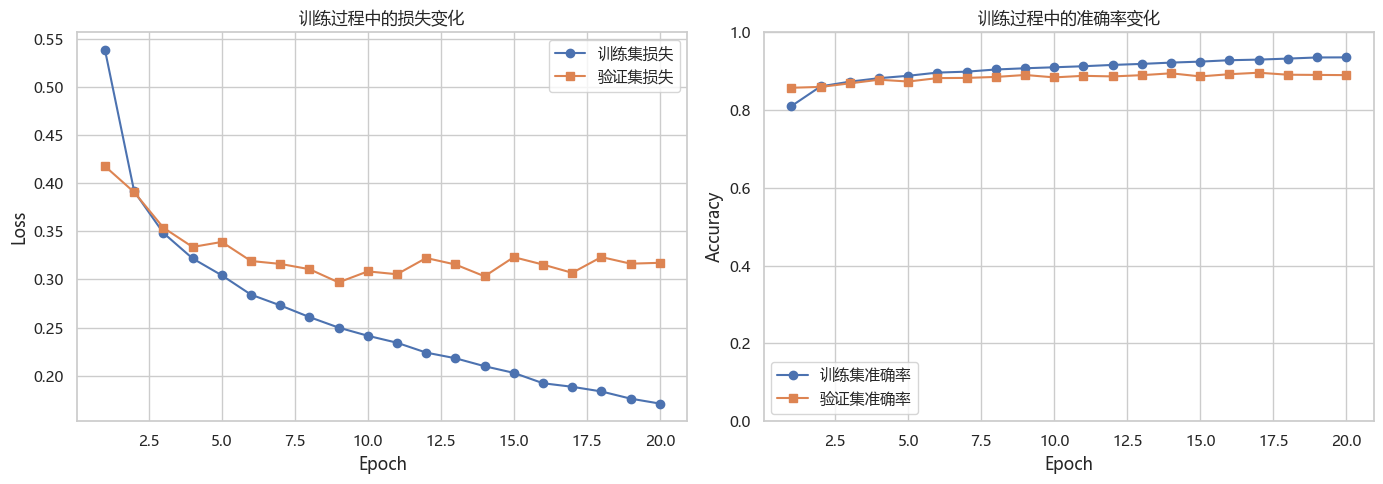

In [7]:
def plot_history(history_df: pd.DataFrame) -> None:
    """
    绘制训练集和验证集的损失、准确率曲线。

    参数：
    - history_df: train_model 返回的训练记录表
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(
        history_df["epoch"],
        history_df["train_loss"],
        marker="o",
        label="训练集损失",
    )
    axes[0].plot(
        history_df["epoch"],
        history_df["valid_loss"],
        marker="s",
        label="验证集损失",
    )
    axes[0].set_title("训练过程中的损失变化")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(
        history_df["epoch"],
        history_df["train_accuracy"],
        marker="o",
        label="训练集准确率",
    )
    axes[1].plot(
        history_df["epoch"],
        history_df["valid_accuracy"],
        marker="s",
        label="验证集准确率",
    )
    axes[1].set_title("训练过程中的准确率变化")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0, 1.0)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_history(history_df)


## 第 7 步：在测试集上做最终评估

验证集主要用于训练过程中挑选较好的模型，
测试集才是最后用来衡量模型泛化能力的数据。

这里我们输出两个指标：

- `test_loss`
  测试集平均损失
- `test_accuracy`
  测试集准确率

这两个结果可以作为后面任务二、任务三、任务四的比较基线。


In [8]:
test_loss, test_acc = run_one_epoch(
    model=model,
    dataloader=test_loader,
    criterion=criterion,
    optimizer=None,
    device=device,
)

print("测试集结果：")
print(f"test_loss={test_loss:.4f}")
print(f"test_accuracy={test_acc:.4f}")


测试集结果：
test_loss=0.3327
test_accuracy=0.8890


## 实验小结

到这里，任务一已经完整完成。

你后面写实验报告时，可以从下面几个角度展开分析：

- 训练损失和验证损失是否整体下降；
- 训练准确率和验证准确率是否整体上升；
- 最佳验证准确率出现在第几轮；
- 训练集和验证集之间有没有明显差距；
- 这个基础模型为什么可以作为后面实验的基线模型。
